# 3. K-Fold Gene Stability Analysis

**Schemat:**
1. Podział train/test (holdout) — test nie jest dotykany podczas selekcji genów
2. 10-fold CV **tylko na zbiorze treningowym** → selekcja stabilnych genów przez SHAP
3. Walidacja na holdout test — tylko AUC, dla różnych rozmiarów top-K genów

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import shap
from collections import Counter, defaultdict
from matplotlib import pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from utilz.Dataset import load_dataset
from utilz.constans import DISEASE, HEALTHY
from utilz.preprocessing_utilz import (
    ConstantExpressionReductor, AnovaReductor,
    MeanExpressionReductor, CovariatesBiasReductor,
    WithinGroupVarianceReductor, AnovaFdrReductor,
)

meta_path = r"../data/samples_pancreatic.xlsx"
data_path = r"../data/counts_pancreatic.csv"
ds = load_dataset(data_path, meta_path, label_col="Group")

# ── hyperparameters ──────────────────────────────────────────────
N_SPLITS            = 10
TOP_K               = 100    # top-K genów per fold liczonych do fold_count
TEST_SIZE           = 0.2    # holdout test
ANOVA_PERCENTILE    = 5
MEAN_PERCENTILE     = 5
WITHIN_GROUP_VAR_P  = 95
ANOVA_FDR_THRESHOLD = 0.1
ANOVA_FDR_THRESHOLD = 0.1

[INFO] skipped 1973 probs due to missing metadata
Dropping inconsistent sample:
                        Sex   Age                Group   Institution  \
Vumc-ChronPan-29-TR1045   M  58.0  Pancreatic diseases  Institute 13   

                         Lib.size Stage RealLocation    Mode  CA125  \
Vumc-ChronPan-29-TR1045   1493422    IV         VUMC  Single    NaN   

                         Platelets Histology   Datasplit Gdansk_sample_name  \
Vumc-ChronPan-29-TR1045        NaN       NaN  Validation                NaN   

                        StageFull  LeukoMichal      PTPRC  
Vumc-ChronPan-29-TR1045        IV  7726.550165  97.092449  


In [2]:
ds.y = ds.y.replace({DISEASE: HEALTHY})

le = LabelEncoder()
y_encoded = pd.Series(le.fit_transform(ds.y), index=ds.y.index)
sex_numeric = ds.sex.map({"F": 0, "M": 1})

print("Class mapping:")
for cls in le.classes_:
    print(f"  {cls} -> {le.transform([cls])[0]}")
print("\nClass distribution:")
print(y_encoded.value_counts().sort_index())

Class mapping:
  Asymptomatic controls -> 0
  Pancreatic cancer -> 1

Class distribution:
0    459
1    124
Name: count, dtype: int64


In [3]:
# ── 1. Holdout train/test split ──────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = ds.get_train_test_valid_split(
    ds.X, y_encoded, test_size=TEST_SIZE, valid_size=0, return_valid=False
)

print(f"\nHoldout split:")
print(f"  Train: {len(X_train_raw)}  (cancer={y_train.sum()}, ctrl={(y_train==0).sum()})")
print(f"  Test:  {len(X_test_raw)}   (cancer={y_test.sum()},  ctrl={(y_test==0).sum()})")

# ── 2. K-Fold tylko na zbiorze treningowym ───────────────────────
folds = ds.get_stratified_kfold(X_train_raw, y_train, n_splits=N_SPLITS, random_state=21)
print(f"\nK-Fold splits within train set: {len(folds)}")

[INFO] 7 samples with unique strata added to train set

Holdout split:
  Train: 467  (cancer=100, ctrl=367)
  Test:  116   (cancer=24,  ctrl=92)
[INFO] Generated 10 folds. Remainder (7) added to training set in each fold.

K-Fold splits within train set: 10


## Main loop — train + SHAP per fold

In [4]:
from utilz.preprocessing_utilz import CovariatesResidualTransformer


def build_pipeline():
    return Pipeline([
        ('ConstantExpressionReductor', ConstantExpressionReductor()),
        ('AnovaFDRReductor',           AnovaFdrReductor(alpha=ANOVA_FDR_THRESHOLD)),
        ('AnovaReductor',              AnovaReductor(percentile=ANOVA_PERCENTILE)),
        ('WithinGroupVarianceReductor',WithinGroupVarianceReductor(WITHIN_GROUP_VAR_P)),
        ('MeanExpressionReductor',     MeanExpressionReductor(percentile=MEAN_PERCENTILE)),
        ('AgeBiasReductor',            CovariatesResidualTransformer(covariate=ds.age)),
        ('SexBiasReductor',            CovariatesResidualTransformer(covariate=ds.age, labels=y_encoded)),
        ('scaler',                     StandardScaler()),
    ])

def snr(shap_matrix):
    """|mean(SHAP)| / std(SHAP) per gene."""
    eps = 1e-10
    return np.abs(shap_matrix.mean(axis=0)) / (shap_matrix.std(axis=0) + eps)

def minmax_norm(x):
    return (x - x.min()) / (x.max() - x.min() + 1e-10)


gene_scores_per_fold = defaultdict(list)

for fold_idx, (tr_idx, va_idx) in enumerate(folds):
    print(f"FOLD {fold_idx + 1}/{N_SPLITS}  train={len(tr_idx)}  val={len(va_idx)}")

    X_tr_raw = X_train_raw.iloc[tr_idx]
    X_va_raw = X_train_raw.iloc[va_idx]
    y_tr     = y_train.iloc[tr_idx]
    y_va     = y_train.iloc[va_idx]

    pipe  = build_pipeline()
    X_tr  = pipe.fit_transform(X_tr_raw, y_tr)
    X_va  = pipe.transform(X_va_raw)
    feature_names = list(pipe.named_steps['SexBiasReductor'].selected_genes_)
    print(f"  features: {len(feature_names)}")

    scale_pos_weight = Counter(y_tr)[0] / Counter(y_tr)[1]
    logreg = LogisticRegression(solver='saga', max_iter=15000, class_weight='balanced',
                                fit_intercept=True, l1_ratio=0.2, random_state=2137)
    xgb    = XGBClassifier(scale_pos_weight=scale_pos_weight, n_estimators=500,
                           random_state=2137, verbosity=0)
    lgbm   = LGBMClassifier(n_estimators=200, learning_rate=0.05,
                            random_state=42, verbose=-1)

    for model in [logreg, xgb, lgbm]:
        model.fit(X_tr, y_tr)

    auc_lr   = roc_auc_score(y_va, logreg.predict_proba(X_va)[:, 1])
    auc_xgb  = roc_auc_score(y_va, xgb.predict_proba(X_va)[:, 1])
    auc_lgbm = roc_auc_score(y_va, lgbm.predict_proba(X_va)[:, 1])
    auc_arr  = np.array([auc_lr, auc_xgb, auc_lgbm])
    w        = auc_arr / auc_arr.sum()
    print(f"  AUC  logreg={auc_lr:.4f}  xgb={auc_xgb:.4f}  lgbm={auc_lgbm:.4f}")

    # SHAP -- zachowujemy pelna macierz (probki x geny) do liczenia SNR
    sv_lr       = shap.LinearExplainer(logreg, X_tr).shap_values(X_va)
    sv_lgbm_raw = shap.TreeExplainer(lgbm).shap_values(X_va)
    sv_lgbm     = sv_lgbm_raw[1] if isinstance(sv_lgbm_raw, list) else sv_lgbm_raw
    sv_xgb      = shap.TreeExplainer(xgb).shap_values(X_va)

    # |mean(SHAP)| / std(SHAP)
    score_lr   = snr(sv_lr)
    score_lgbm = snr(sv_lgbm)
    score_xgb  = snr(sv_xgb)

    weighted_score = (
        minmax_norm(score_lr)   * w[0] +
        minmax_norm(score_xgb)  * w[1] +
        minmax_norm(score_lgbm) * w[2]
    )

    fold_gene_score = dict(zip(feature_names, weighted_score))
    for gene in feature_names:
        if gene not in gene_scores_per_fold:
            gene_scores_per_fold[gene] = [0.0] * fold_idx
    all_seen = set(gene_scores_per_fold.keys()) | set(feature_names)
    for gene in all_seen:
        gene_scores_per_fold[gene].append(fold_gene_score.get(gene, 0.0))

for gene in gene_scores_per_fold:
    while len(gene_scores_per_fold[gene]) < N_SPLITS:
        gene_scores_per_fold[gene].append(0.0)

lengths = set(len(v) for v in gene_scores_per_fold.values())
print(f"Done. Genes tracked: {len(gene_scores_per_fold)}, list lengths: {lengths}")


FOLD 1/10  train=421  val=46
data shape after ConstantExpressionReductor:  (421, 31625)
data shape after AnovaFdrReductor:  (421, 3034)
data shape after AnovaReductor:  (421, 2882)
data shape after WithinGroupVarianceReductor:  (421, 2737)
data shape after MeanExpressionReductor:  (421, 2600)
data shape after CovariatesResidualTransformer: (421, 2600)
data shape after CovariatesResidualTransformer: (421, 2600)
data shape after ConstantExpressionReductor:  (46, 31625)
data shape after AnovaFdrReductor:  (46, 3034)
data shape after AnovaReductor:  (46, 2882)
data shape after WithinGroupVarianceReductor:  (46, 2737)
data shape after MeanExpressionReductor:  (46, 2600)
data shape after CovariatesResidualTransformer: (46, 2600)
data shape after CovariatesResidualTransformer: (46, 2600)
  features: 2600
  AUC  logreg=0.9278  xgb=0.8972  lgbm=0.8944
FOLD 2/10  train=421  val=46
data shape after ConstantExpressionReductor:  (421, 31719)
data shape after AnovaFdrReductor:  (421, 2218)
data shap

## Aggregation across folds

In [5]:
# top-K set per fold
fold_topk_genes = []
for fold_idx in range(N_SPLITS):
    scores_this_fold = {
        gene: scores[fold_idx]
        for gene, scores in gene_scores_per_fold.items()
        if scores[fold_idx] > 0
    }
    topk = sorted(scores_this_fold, key=scores_this_fold.get, reverse=True)[:TOP_K]
    fold_topk_genes.append(set(topk))

# summary dataframe
records = []
for gene, scores in gene_scores_per_fold.items():
    s = np.array(scores)
    records.append({
        'gene':         gene,
        'fold_count':   sum(1 for fset in fold_topk_genes if gene in fset),
        'mean_score':   s.mean(),
        'median_score': np.median(s),
        'max_score':    s.max(),
        'nonzero_mean': s[s > 0].mean() if (s > 0).any() else 0.0,
    })

stability_df = (
    pd.DataFrame(records)
    .sort_values(['fold_count', 'mean_score'], ascending=[False, False])
    .reset_index(drop=True)
)
stability_df.index += 1
stability_df.index.name = 'rank'

print(f"Total unique genes seen across all folds: {len(stability_df)}")
print(f"\nTop 30 most stable genes:")
stability_df.head(30)

Total unique genes seen across all folds: 5554

Top 30 most stable genes:


,gene,fold_count,mean_score,median_score,max_score,nonzero_mean
rank,,,,,,
1,ENSG00000123570,5,0.292649,0.230816,0.962541,0.292649
2,ENSG00000165949,5,0.233448,0.119796,0.668536,0.233448
3,ENSG00000137216,5,0.226258,0.190789,0.419891,0.226258
4,ENSG00000130203,5,0.205734,0.230670,0.348184,0.205734
5,ENSG00000111077,5,0.196280,0.166800,0.510937,0.280400
6,ENSG00000073712,5,0.179647,0.219898,0.358513,0.179647
7,ENSG00000186314,5,0.156993,0.168131,0.293379,0.156993
8,ENSG00000239839,4,0.253182,0.221168,0.685683,0.253182
9,ENSG00000158874,4,0.217324,0.176092,0.500804,0.217324


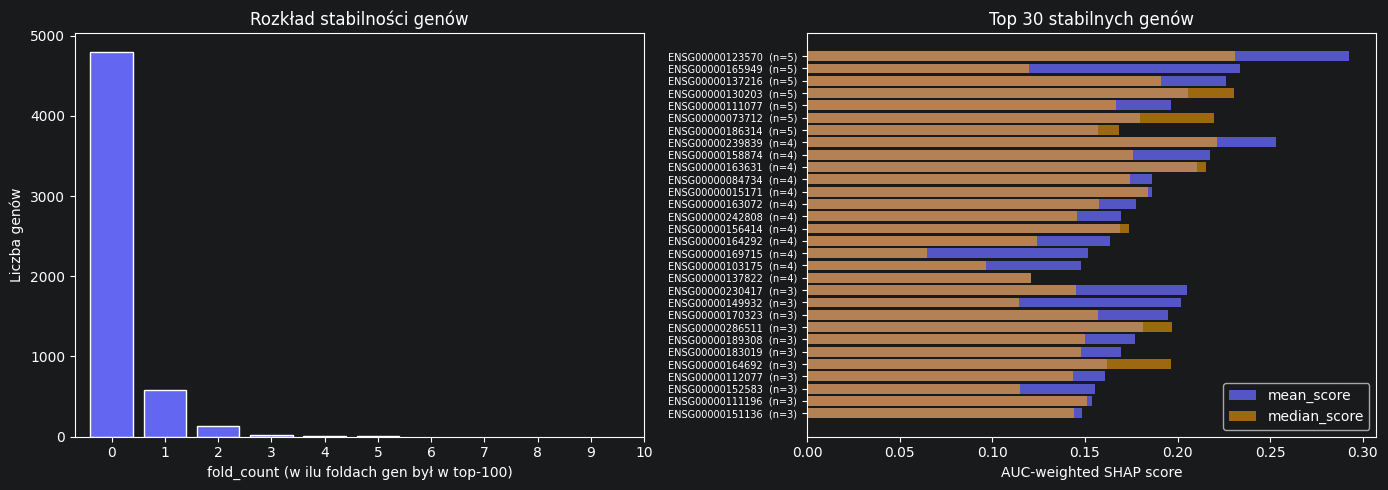

In [6]:
# rozkład fold_count
fc_counts = stability_df['fold_count'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(fc_counts.index, fc_counts.values, color='#6366f1', edgecolor='white')
#logarytmiczna skala y

axes[0].set_xlabel('fold_count (w ilu foldach gen był w top-100)')
axes[0].set_ylabel('Liczba genów')
axes[0].set_title('Rozkład stabilności genów')
axes[0].set_xticks(range(0, N_SPLITS + 1))

top30 = stability_df.head(30)
y_pos = np.arange(len(top30))
axes[1].barh(y_pos, top30['mean_score'],   color='#6366f1', alpha=0.8, label='mean_score')
axes[1].barh(y_pos, top30['median_score'], color='#f59e0b', alpha=0.6, label='median_score')
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(
    [f"{g}  (n={int(n)})" for g, n in zip(top30['gene'], top30['fold_count'])],
    fontsize=7
)
axes[1].invert_yaxis()
axes[1].set_xlabel('AUC-weighted SHAP score')
axes[1].set_title('Top 30 stabilnych genów')
axes[1].legend()
plt.tight_layout()
plt.show()

## Greedy forward gene selection (wewnatrz CV) + walidacja na holdout

1. Greedy forward selection na **zbiorze treningowym** z wewnetrznym k-fold CV (AUC)
2. Holdout test sluzy **wylacznie** do finalnej weryfikacji wybranego zestawu genow

In [7]:
# ── pipeline na pelnym train (do finalnej walidacji) ─────────────
pipe_full = build_pipeline()
X_tr_full = pipe_full.fit_transform(X_train_raw, y_train)
X_te_full = pipe_full.transform(X_test_raw)
all_feature_names = list(pipe_full.named_steps['SexBiasReductor'].selected_genes_)

X_tr_df = pd.DataFrame(X_tr_full, columns=all_feature_names)
X_te_df = pd.DataFrame(X_te_full, columns=all_feature_names)

# ── RFE (Recursive Feature Elimination) z CV ────────────────────
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold as SKF

CANDIDATE_POOL = 100
MIN_FEATURES   = 1
INNER_SPLITS   = 5

candidates_all = stability_df.head(CANDIDATE_POOL)['gene'].tolist()
candidates = [g for g in candidates_all if g in all_feature_names]
print(f"Kandydaci: {len(candidates)} genow (z top-{CANDIDATE_POOL} stability)")

X_tr_cand = X_tr_df[candidates]
X_te_cand = X_te_df[candidates]

scale_pos_weight = Counter(y_train)[0] / Counter(y_train)[1]

# RFE z LogReg (ma coef_ -> ranking waznosci)
base_estimator = LogisticRegression(
    solver='saga', max_iter=15000,
    class_weight='balanced', fit_intercept=True
)

inner_cv = SKF(n_splits=INNER_SPLITS, shuffle=True, random_state=42)

rfecv = RFECV(
    estimator=base_estimator,
    step=1,
    cv=inner_cv,
    scoring='roc_auc',
    min_features_to_select=MIN_FEATURES,
    n_jobs=-1,
    verbose=0,
)

print("Uruchamiam RFECV...")
rfecv.fit(X_tr_cand.values, y_train.values)

# ── ranking genow z RFE ─────────────────────────────────────────
rfe_ranking = pd.DataFrame({
    'gene': candidates,
    'rfe_rank': rfecv.ranking_,
    'selected': rfecv.support_,
}).sort_values('rfe_rank')

best_n = rfecv.n_features_
best_genes = rfe_ranking[rfe_ranking['selected']]['gene'].tolist()
print(f"\nRFECV wybral {best_n} genow (z {len(candidates)} kandydatow)")
print(f"Wybrane geny: {best_genes}")

# ── geny posortowane wg RFE ranking (najwazniejsze pierwsze) ────
genes_by_rank = rfe_ranking.sort_values('rfe_rank')['gene'].tolist()

# cv_results -> krzywa AUC vs n_features
cv_scores = rfecv.cv_results_['mean_test_score']

def test_auc(gene_list):
    """AUC na holdout test — tylko do wyswietlania, nie do decyzji."""
    X_tr = X_tr_df[gene_list].values
    X_te = X_te_df[gene_list].values
    spw = Counter(y_train)[0] / Counter(y_train)[1]
    aucs = {}
    for name, model in [
        ('logreg', LogisticRegression(solver='saga', max_iter=15000,
                                      class_weight='balanced', fit_intercept=True)),
        ('xgb',    XGBClassifier(scale_pos_weight=spw, n_estimators=500,
                                 random_state=2137, verbosity=0)),
        ('lgbm',   LGBMClassifier(n_estimators=200, learning_rate=0.05,
                                  random_state=42, verbose=-1)),
    ]:
        model.fit(X_tr, y_train)
        aucs[name] = roc_auc_score(y_test, model.predict_proba(X_te)[:, 1])
    aucs['mean'] = np.mean(list(aucs.values()))
    return aucs

history = []
for k in range(1, len(candidates) + 1):
    genes_k = genes_by_rank[:k]
    t = test_auc(genes_k)
    cv_idx = k - MIN_FEATURES
    cv_auc_k = cv_scores[cv_idx] if cv_idx < len(cv_scores) else np.nan
    history.append({
        'n_genes':       k,
        'added_gene':    genes_by_rank[k - 1],
        'cv_mean_auc':   cv_auc_k,
        'test_logreg':   t['logreg'],
        'test_xgb':      t['xgb'],
        'test_lgbm':     t['lgbm'],
        'test_mean_auc': t['mean'],
    })
    print(f"  n={k:>3}: +{genes_by_rank[k-1]:25s}  "
          f"cv={cv_auc_k:.4f}  "
          f"test: lr={t['logreg']:.4f} xgb={t['xgb']:.4f} lgbm={t['lgbm']:.4f} mean={t['mean']:.4f}")

greedy_df = pd.DataFrame(history)
print(f"\nNajlepszy CV AUC (RFECV): {cv_scores.max():.4f} przy {best_n} genach")
print(f"Test mean AUC przy tym progu: {greedy_df.loc[greedy_df['n_genes']==best_n, 'test_mean_auc'].values[0]:.4f}")
print(f"Wybrane geny: {best_genes}")

data shape after ConstantExpressionReductor:  (467, 32261)
data shape after AnovaFdrReductor:  (467, 4326)
data shape after AnovaReductor:  (467, 4109)
data shape after WithinGroupVarianceReductor:  (467, 3903)
data shape after MeanExpressionReductor:  (467, 3707)
data shape after CovariatesResidualTransformer: (467, 3707)
data shape after CovariatesResidualTransformer: (467, 3707)
data shape after ConstantExpressionReductor:  (116, 32261)
data shape after AnovaFdrReductor:  (116, 4326)
data shape after AnovaReductor:  (116, 4109)
data shape after WithinGroupVarianceReductor:  (116, 3903)
data shape after MeanExpressionReductor:  (116, 3707)
data shape after CovariatesResidualTransformer: (116, 3707)
data shape after CovariatesResidualTransformer: (116, 3707)
Kandydaci: 100 genow (z top-100 stability)
Uruchamiam RFECV...

RFECV wybral 64 genow (z 100 kandydatow)
Wybrane geny: ['ENSG00000123570', 'ENSG00000137216', 'ENSG00000130203', 'ENSG00000111077', 'ENSG00000186314', 'ENSG0000007371

In [8]:
# ── finalna walidacja na holdout test ────────────────────────────
print(f"\n{'='*60}")
print(f"WALIDACJA NA HOLDOUT TEST (n={len(X_test_raw)}) — {best_n} genow")
print('='*60)

X_tr_final = X_tr_df[best_genes].values
X_te_final = X_te_df[best_genes].values

for name, model in [
    ('LogReg', LogisticRegression(solver='saga', max_iter=15000,
                                  class_weight='balanced', fit_intercept=True)),
    ('XGB',    XGBClassifier(scale_pos_weight=scale_pos_weight,
                             n_estimators=500, random_state=2137, verbosity=0)),
    ('LGBM',   LGBMClassifier(n_estimators=200, learning_rate=0.05,
                              random_state=42, verbose=-1)),
]:
    model.fit(X_tr_final, y_train)
    auc = roc_auc_score(y_test, model.predict_proba(X_te_final)[:, 1])
    print(f"  {name:6s}  AUC = {auc:.4f}")

print(f"\nRFE ranking (top 20):")
print(rfe_ranking.head(20).to_string(index=False))


WALIDACJA NA HOLDOUT TEST (n=116) — 64 genow
  LogReg  AUC = 0.8030
  XGB     AUC = 0.8351
  LGBM    AUC = 0.8551

RFE ranking (top 20):
           gene  rfe_rank  selected
ENSG00000123570         1      True
ENSG00000137216         1      True
ENSG00000130203         1      True
ENSG00000111077         1      True
ENSG00000186314         1      True
ENSG00000073712         1      True
ENSG00000084734         1      True
ENSG00000158874         1      True
ENSG00000164292         1      True
ENSG00000156414         1      True
ENSG00000015171         1      True
ENSG00000163072         1      True
ENSG00000149932         1      True
ENSG00000170323         1      True
ENSG00000286511         1      True
ENSG00000230417         1      True
ENSG00000271736         1      True
ENSG00000157764         1      True
ENSG00000111196         1      True
ENSG00000183019         1      True


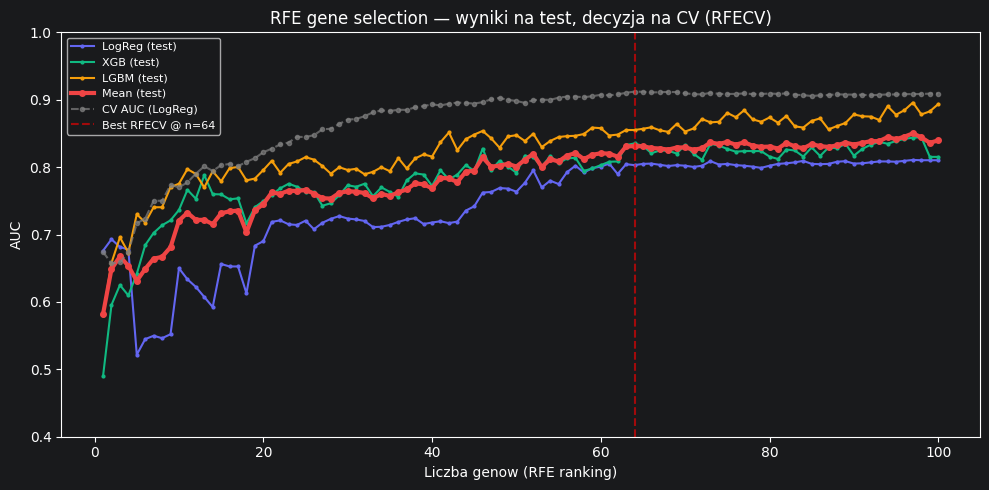

Zapisano: gene_stability_kfold.csv, rfe_gene_selection.csv, rfe_ranking.csv


In [9]:
# wykres: test AUC vs liczba genow (RFE ranking, decyzja na CV)
fig, ax = plt.subplots(figsize=(10, 5))
x = greedy_df['n_genes']

for col, label, color in [
    ('test_logreg',   'LogReg (test)', '#6366f1'),
    ('test_xgb',      'XGB (test)',    '#10b981'),
    ('test_lgbm',     'LGBM (test)',   '#f59e0b'),
    ('test_mean_auc', 'Mean (test)',   '#ef4444'),
]:
    lw = 3 if 'mean' in col else 1.5
    ms = 'o' if 'mean' in col else '.'
    ax.plot(x, greedy_df[col], marker=ms, label=label, color=color, linewidth=lw, markersize=4)

# CV AUC (LogReg z RFECV) jako druga krzywa
ax.plot(x, greedy_df['cv_mean_auc'], marker='.', label='CV AUC (LogReg)', 
        color='gray', linewidth=1.5, linestyle='--', alpha=0.7)

# pionowa linia = optimum wg RFECV
ax.axvline(best_n, ls='--', color='red', alpha=0.6,
           label=f"Best RFECV @ n={best_n}")

ax.set_xlabel('Liczba genow (RFE ranking)')
ax.set_ylabel('AUC')
ax.set_title('RFE gene selection — wyniki na test, decyzja na CV (RFECV)')
ax.legend(fontsize=8)
ax.set_ylim(0.4, 1.0)
plt.tight_layout()
plt.show()

stability_df.to_csv('gene_stability_kfold.csv', index=True)
greedy_df.to_csv('rfe_gene_selection.csv', index=False)
rfe_ranking.to_csv('rfe_ranking.csv', index=False)
print("Zapisano: gene_stability_kfold.csv, rfe_gene_selection.csv, rfe_ranking.csv")